## Imports

In [68]:
import sys
import os
import torch
import torch.utils.data as data
import torch.nn as nn

sys.path.append(os.path.abspath('../'))

from neuro_fuzzy_toolbox import ANFIS, Hybrid_learning_algorithm, EarlyStopping, get_measures

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [70]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Regression

## Data

In [71]:
def z(x, y):
  return ((3) * ((1-x)**2) * (np.exp(-(x**2)-((y+1)**2))) - (10) * ((x/5)-(x**3)-(y**5)) * (np.exp(-(x**2)-(y**2))) - (1/3)*np.exp(-(x+1)**2-(y**2)))

#Training
x0 = np.random.uniform(-3,3,10000)
x1 = np.random.uniform(-3,3,10000)

e = np.random.normal(0,0.1,10000) #noise
Y = z(x0,x1) + e

#Testing
x0_test = np.random.uniform(-3,3,10000)
x1_test = np.random.uniform(-3,3,10000)

Y_test = z(x0_test,x1_test)

In [72]:
#Training
scaler = MinMaxScaler(feature_range=(0, 1))
vstack_train = np.vstack((x0,x1)).T
scaled_train = scaler.fit_transform(vstack_train)

#Testing
vstack_test = np.vstack((x0_test,x1_test)).T
scaled_test = scaler.transform(vstack_test)

In [73]:
train_loader = data.DataLoader(data.TensorDataset(torch.from_numpy(scaled_train), torch.from_numpy(Y)), batch_size = 128, shuffle = True)
x_train = train_loader.dataset.tensors[0]
y_train = train_loader.dataset.tensors[1]

test_loader = data.DataLoader(data.TensorDataset(torch.from_numpy(scaled_test), torch.from_numpy(Y_test)), batch_size = 128, shuffle = True)
x_test = test_loader.dataset.tensors[0]
y_test = test_loader.dataset.tensors[1]

## Model & Training

In [74]:
model = ANFIS(
    input_size = 2,
    fuzzy_rules = 6,
    outputs = 1,
    rule_reduced = False
)
model.init_premises(x_train)
model.show_premises_structure()

              a (x0)  b (x0)  c (x0)  a (x1)  b (x1)  c (x1)
Fuzzy rule 1     0.1     8.0     0.0     0.1     8.0     0.0
Fuzzy rule 2     0.1     8.0     0.2     0.1     8.0     0.2
Fuzzy rule 3     0.1     8.0     0.4     0.1     8.0     0.4
Fuzzy rule 4     0.1     8.0     0.6     0.1     8.0     0.6
Fuzzy rule 5     0.1     8.0     0.8     0.1     8.0     0.8
Fuzzy rule 6     0.1     8.0     1.0     0.1     8.0     1.0


In [78]:
loss_fn = nn.functional.mse_loss
#loss_fn = nn.functional.binary_cross_entropy
#loss_fn = nn.functional.cross_entropy

optimizer = torch.optim.AdamW
params = {'lr': 0.0001, 'weight_decay': 0.001}

early_stopping = EarlyStopping(patience=10, delta=0.01)

trainer = Hybrid_learning_algorithm(
    epochs=200,
    loss_function=loss_fn,
    optimizer=optimizer,
    optimizer_params=params,
    validation=0.4,
    early_stopping=early_stopping
)

In [79]:
trainer(model, train_loader, verbose=True)

Epoch: 1/200 - loss: 0.16708979730016554 - validation loss: 0.1668710218532833
Epoch: 2/200 - loss: 0.13448337563465876 - validation loss: 0.1337022565965264
Epoch: 3/200 - loss: 0.10537606237319043 - validation loss: 0.1031004156311488
Epoch: 4/200 - loss: 0.08406820353479738 - validation loss: 0.08115893980892483
Epoch: 5/200 - loss: 0.07012686461843996 - validation loss: 0.06750363931485982
Epoch: 6/200 - loss: 0.06168322762388791 - validation loss: 0.0595048077582192
Epoch: 7/200 - loss: 0.055898393304836244 - validation loss: 0.054172629196557895
Epoch: 8/200 - loss: 0.05164577696568191 - validation loss: 0.05035661464266953
Epoch: 9/200 - loss: 0.048613491596723804 - validation loss: 0.047437814281152645
Epoch: 10/200 - loss: 0.04659019922133604 - validation loss: 0.045682308666889854
Epoch: 11/200 - loss: 0.04522776515702525 - validation loss: 0.04445362803616797
Epoch: 12/200 - loss: 0.044285072076503146 - validation loss: 0.043683122409190554
Epoch: 13/200 - loss: 0.0434361259

In [80]:
model.show_premises_structure()

                a (x0)    b (x0)    c (x0)    a (x1)    b (x1)    c (x1)
Fuzzy rule 1  0.136112  7.966840  0.035932  0.126960  7.972018  0.026642
Fuzzy rule 2  0.119766  7.963785  0.220586  0.116804  7.958562  0.216945
Fuzzy rule 3  0.113026  7.961330  0.403483  0.112968  7.959101  0.399828
Fuzzy rule 4  0.116497  7.962367  0.584821  0.119182  7.961453  0.593362
Fuzzy rule 5  0.127321  7.956207  0.772629  0.116746  7.953827  0.784888
Fuzzy rule 6  0.136212  7.964689  0.964228  0.126218  7.972655  0.974368


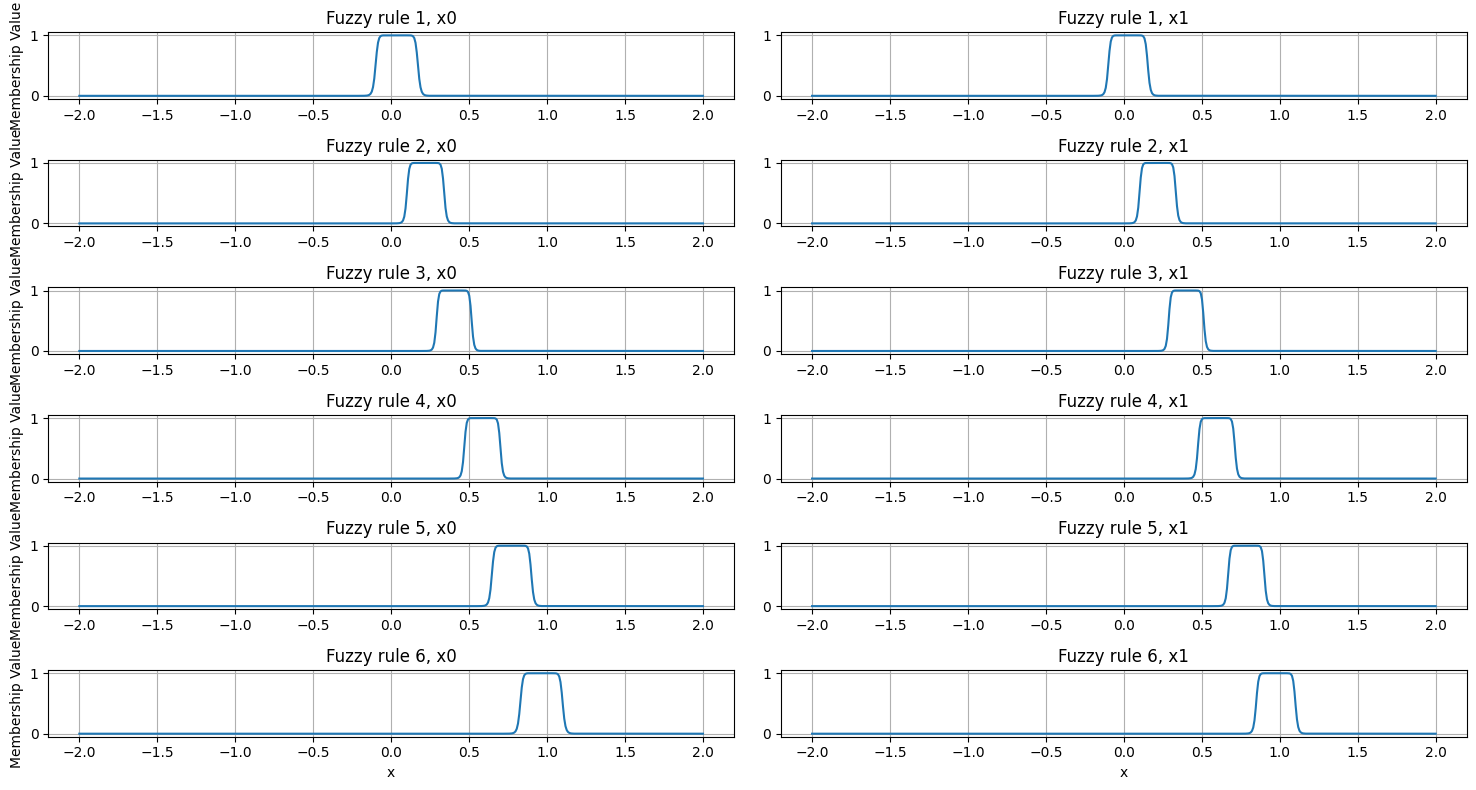

In [81]:
model.plot_premises()

In [82]:
x_test = test_loader.dataset.tensors[0]
y_test = test_loader.dataset.tensors[1]

test_measures = get_measures(model, x_test, y_test)

for measure in test_measures:
    print(measure + ':', test_measures[measure])

MSE: 0.03581261749264073
RMSE: 0.1892422191072614
MAE: 0.12297732313160202
R2: 0.9900716028989296
MAPE: 11.436036009192904


In [83]:
train_measures = get_measures(model, x_train, y_train)

for measure in train_measures:
    print(measure + ':', train_measures[measure])

MSE: 0.044044292209578104
RMSE: 0.20986732048982307
MAE: 0.1527232449061836
R2: 0.9878199238901804
MAPE: 1.6389343545037347


# Binary Classification

## Data

In [24]:
from ucimlrepo import fetch_ucirepo

In [25]:
parkinsons = fetch_ucirepo(id=174)

X = parkinsons.data.features
y = parkinsons.data.targets

In [26]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)

In [27]:
unique_classes, counts = np.unique(y_train.values, return_counts=True)
print(unique_classes)
print(counts)

[0 1]
[ 33 103]


In [28]:
unique_classes, counts = np.unique(y_test.values, return_counts=True)
print(unique_classes)
print(counts)

[0 1]
[15 44]


In [29]:
scaler = MinMaxScaler(feature_range=(0, 1))

x_train = scaler.fit_transform(x_train)

x_test = scaler.transform(x_test)

In [30]:
x_train = torch.from_numpy(x_train)
x_test = torch.from_numpy(x_test)
y_train = torch.from_numpy(y_train.values).squeeze()
y_test = torch.from_numpy(y_test.values).squeeze()

In [31]:
train_loader = data.DataLoader(data.TensorDataset(x_train, y_train), batch_size = 8, shuffle = True)
x_train = train_loader.dataset.tensors[0]
y_train = train_loader.dataset.tensors[1]

## Model & Training

In [50]:
model = ANFIS(
    input_size = 22,
    fuzzy_rules = 15,
    outputs = 1,
    rule_reduced = True,
    output_type='binary',
    dtype=torch.float64
)

model.init_premises(x_train)

In [51]:
loss_fn = nn.functional.binary_cross_entropy

#optimizer = torch.optim.AdamW
#params = {'lr': 0.01, 'weight_decay': 0.1}
#optimizer = torch.optim.Adam
#params = {'lr': 0.005}
optimizer = torch.optim.SGD
params = {'lr': 0.001, 'momentum': 0.9}

early_stopping = EarlyStopping(
    patience=50, 
    delta=0.01
)

In [52]:
trainer = Hybrid_learning_algorithm(
    epochs=500,
    loss_function=loss_fn,
    optimizer=optimizer,
    optimizer_params=params,
    validation=0.3,
    early_stopping=early_stopping
)

In [53]:
trainer(model, train_loader, verbose=True)

Epoch: 1/500 - loss: 0.6818478894641232 - validation loss: 0.6862167808098231
Epoch: 2/500 - loss: 0.6753857226798061 - validation loss: 0.6850996632539886
Epoch: 3/500 - loss: 0.6334084353426465 - validation loss: 0.6194271170975075
Epoch: 4/500 - loss: 0.6414290115474838 - validation loss: 0.6686390148035446
Epoch: 5/500 - loss: 0.6415395302709122 - validation loss: 0.66627389150804
Epoch: 6/500 - loss: 0.6415396032001516 - validation loss: 0.666274186421691
Epoch: 7/500 - loss: 0.6434567629314722 - validation loss: 0.6617286400846326
Epoch: 8/500 - loss: 0.6415403464784201 - validation loss: 0.6662751405088105
Epoch: 9/500 - loss: 0.6415403391071698 - validation loss: 0.6662748892333054
Epoch: 10/500 - loss: 0.6415405678905206 - validation loss: 0.6662750731859303
Epoch: 11/500 - loss: 0.6415406317891493 - validation loss: 0.6662751080661626
Epoch: 12/500 - loss: 0.6415406336311752 - validation loss: 0.6662750319429684
Epoch: 13/500 - loss: 0.624173581396114 - validation loss: 0.643

In [54]:
train_measures = get_measures(model, x_train, y_train)
for measure in train_measures:
    print(measure + ':', train_measures[measure])

Accuracy: 0.47794117647058826
Precision: 0.7162162162162162
Recall: 0.5145631067961165
F1: 0.5988700564971752
Confusion Matrix: [[12 21]
 [50 53]]


In [55]:
test_measures = get_measures(model, x_test, y_test)
for measure in test_measures:
    print(measure + ':', test_measures[measure])

Accuracy: 0.5254237288135594
Precision: 0.7222222222222222
Recall: 0.5909090909090909
F1: 0.65
Confusion Matrix: [[ 5 10]
 [18 26]]


# Multiclass Classification

## Data

In [125]:
from ucimlrepo import fetch_ucirepo

In [126]:
heart_disease = fetch_ucirepo(id=45)

X = heart_disease.data.features
y = heart_disease.data.targets

In [127]:
X = X.fillna(value=0)

In [128]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)

In [129]:
unique_classes, counts = np.unique(y_train.values, return_counts=True)
print(unique_classes)
print(counts)

[0 1 2 3 4]
[115  38  25  25   9]


In [130]:
unique_classes, counts = np.unique(y_test.values, return_counts=True)
print(unique_classes)
print(counts)

[0 1 2 3 4]
[49 17 11 10  4]


In [131]:
scaler = MinMaxScaler(feature_range=(0, 1))

x_train = scaler.fit_transform(x_train)

x_test = scaler.transform(x_test)

In [132]:
x_train = torch.from_numpy(x_train)
x_test = torch.from_numpy(x_test)
y_train = torch.from_numpy(y_train.values).squeeze()
y_test = torch.from_numpy(y_test.values).squeeze()

In [133]:
y_train.dtype

torch.int64

In [134]:
x_train = x_train.type(torch.float32)
x_test = x_test.type(torch.float32)

In [135]:
loader = data.DataLoader(data.TensorDataset(x_train, y_train), batch_size = 8, shuffle = True)
x_trainset = loader.dataset.tensors[0]
y_trainset = loader.dataset.tensors[1]

In [136]:
y_trainset.dtype

torch.int64

## Model & Training

In [143]:
model = ANFIS(
    input_size = 13,
    fuzzy_rules = 6,
    outputs = 5,
    rule_reduced = True,
    output_type='multiclass',
    dtype=torch.float32
)

In [144]:
loss_fn = nn.functional.cross_entropy

optimizer = torch.optim.AdamW
params = {'lr': 0.001, 'weight_decay': 0.01}
optimizer = torch.optim.Adam
params = {'lr': 0.005}
#optimizer = torch.optim.SGD
#params = {'lr': 0.01, 'momentum': 0.9}

early_stopping = EarlyStopping(
    patience=50, 
    delta=0.01
)

In [145]:
trainer = Hybrid_learning_algorithm(
    epochs=500,
    loss_function=loss_fn,
    optimizer=optimizer,
    optimizer_params=params,
    validation=0.3,
    early_stopping=early_stopping
)

In [146]:
trainer(model, loader, verbose=True)

Epoch: 1/500 - loss: 1.3718498945236206 - validation loss: 1.3825863599777222
Epoch: 2/500 - loss: 1.3350722789764404 - validation loss: 1.4215943813323975
Epoch: 3/500 - loss: 1.3117010593414307 - validation loss: 1.3998194932937622
Epoch: 4/500 - loss: 1.3362468481063843 - validation loss: 1.3739020824432373
Epoch: 5/500 - loss: 1.5859153270721436 - validation loss: 1.6184499263763428
Epoch: 6/500 - loss: 1.4223904609680176 - validation loss: 1.5644478797912598
Epoch: 7/500 - loss: 1.4996360540390015 - validation loss: 1.9809167385101318
Epoch: 8/500 - loss: 1.4938160181045532 - validation loss: 1.7166868448257446
Epoch: 9/500 - loss: 1.4958093166351318 - validation loss: 1.4518991708755493
Epoch: 10/500 - loss: 1.301424503326416 - validation loss: 1.350709319114685
Epoch: 11/500 - loss: 1.3142294883728027 - validation loss: 1.355526328086853
Epoch: 12/500 - loss: 1.3135584592819214 - validation loss: 1.2724943161010742
Epoch: 13/500 - loss: 1.30022394657135 - validation loss: 1.3620

In [147]:
train_measures = get_measures(model, x_trainset, y_trainset)
for measure in train_measures:
    print(measure + ':', train_measures[measure])

Accuracy: 0.5943396226415094
Precision: 0.5667142021354395
Recall: 0.5943396226415094
F1: 0.5411923906651986
Confusion Matrix: [[103   0   3   9   0]
 [ 21   2   6   9   0]
 [  6   1   9   9   0]
 [  5   1   7  12   0]
 [  3   0   2   4   0]]


In [148]:
test_measures = get_measures(model, x_test, y_test)
for measure in test_measures:
    print(measure + ':', test_measures[measure])

Accuracy: 0.4945054945054945
Precision: 0.49447795312456966
Recall: 0.4945054945054945
F1: 0.4572111676518758
Confusion Matrix: [[37  1  6  5  0]
 [12  1  1  3  0]
 [ 6  0  3  2  0]
 [ 1  0  5  4  0]
 [ 1  0  3  0  0]]
